In [1]:

import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
base = "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset"
label_path = f"{base}/VisDrone2019-DET-train/labels"
image_path = f"{base}/VisDrone2019-DET-train/images"

labels = sorted(os.listdir(label_path))
images = sorted(os.listdir(image_path))

print(f"Total images: {len(images)}")
print(f"Total labels: {len(labels)}")
print(f"\nSample image: {images[0]}")
print(f"Sample label: {labels[0]}")

# Read first label file
with open(f"{label_path}/{labels[0]}", 'r') as f:
    lines = f.readlines()

print(f"\nFirst 5 rows of label file:")
for line in lines[:5]:
    print(f"  {line.strip()}")

Total images: 6471
Total labels: 6471

Sample image: 0000002_00005_d_0000014.jpg
Sample label: 0000002_00005_d_0000014.txt

First 5 rows of label file:
  3 0.776042 0.902778 0.077083 0.061111
  3 0.697396 0.829630 0.063542 0.085185
  3 0.652083 0.786111 0.066667 0.094444
  3 0.617188 0.757407 0.063542 0.070370
  3 0.596354 0.719444 0.067708 0.061111


In [2]:
# === COMPLETE STEP 2: Dataset Exploration & Visualization ===


base = "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset"
train_img = f"{base}/VisDrone2019-DET-train/images"
train_lbl = f"{base}/VisDrone2019-DET-train/labels"
val_img   = f"{base}/VisDrone2019-DET-val/images"
val_lbl   = f"{base}/VisDrone2019-DET-val/labels"

images = sorted(os.listdir(train_img))
labels = sorted(os.listdir(train_lbl))

print(f"✅ Train images: {len(images)}")
print(f"✅ Train labels: {len(labels)}")

✅ Train images: 6471
✅ Train labels: 6471


In [3]:
# === CLASS DEFINITIONS ===
# VisDrone YOLO classes
CLASSES = {
    0: 'pedestrian',
    1: 'people',
    2: 'bicycle',
    3: 'car',
    4: 'van',
    5: 'truck',
    6: 'tricycle',
    7: 'awning-tricycle',
    8: 'bus',
    9: 'motor'
}

COLORS = {
    0: 'red',
    1: 'orange',
    2: 'green',
    3: 'blue',
    4: 'cyan',
    5: 'purple',
    6: 'yellow',
    7: 'pink',
    8: 'brown',
    9: 'lime'
}

# Classes we care about
TARGET = {0: 'pedestrian', 1: 'people', 3: 'car'}

/tmp/ipykernel_22/3866662760.py:50: UserWarning: Glyph 128694 (\N{PEDESTRIAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22/3866662760.py:50: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128694 (\N{PEDESTRIAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


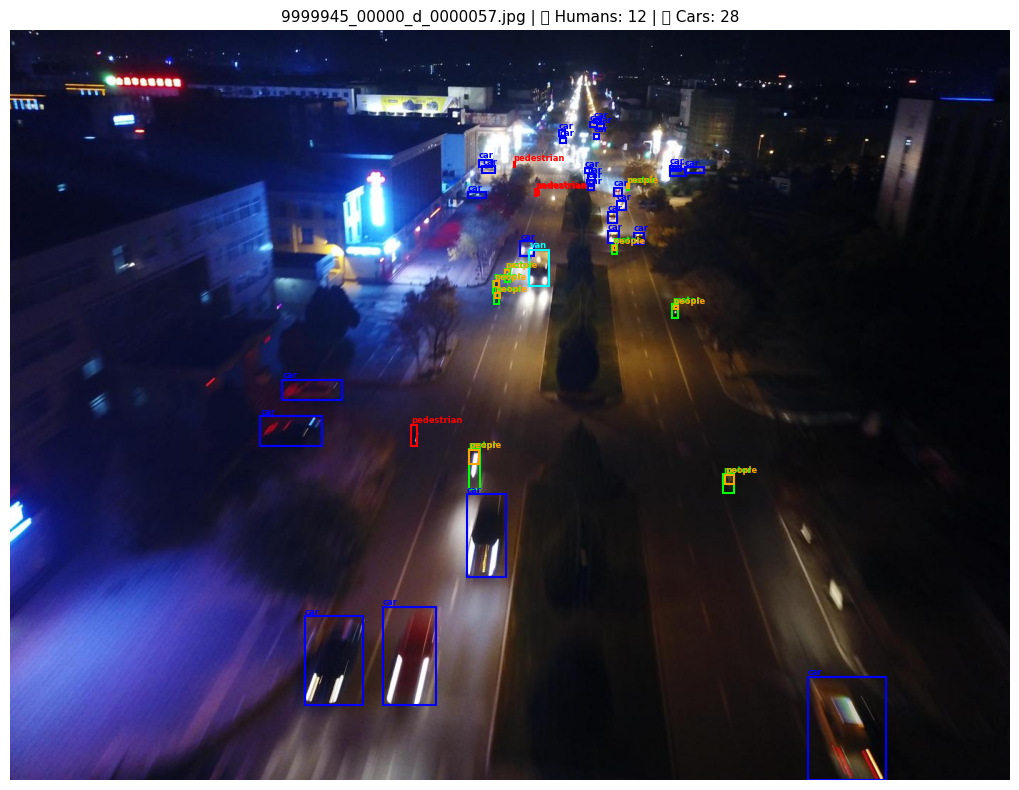

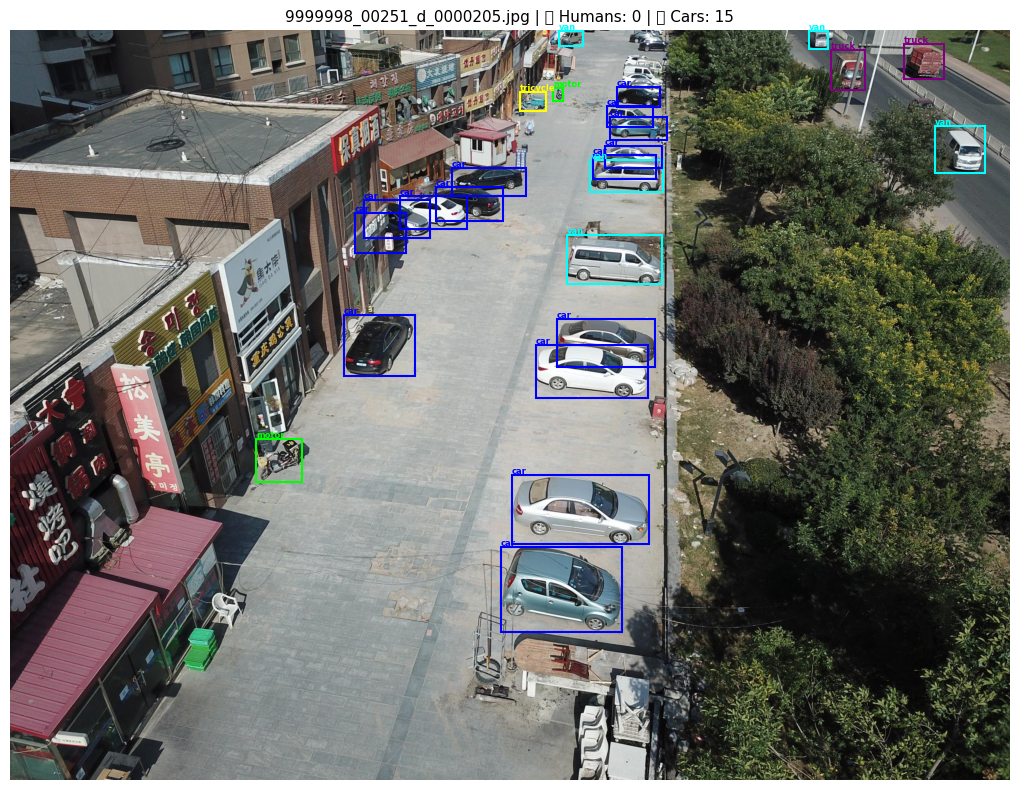

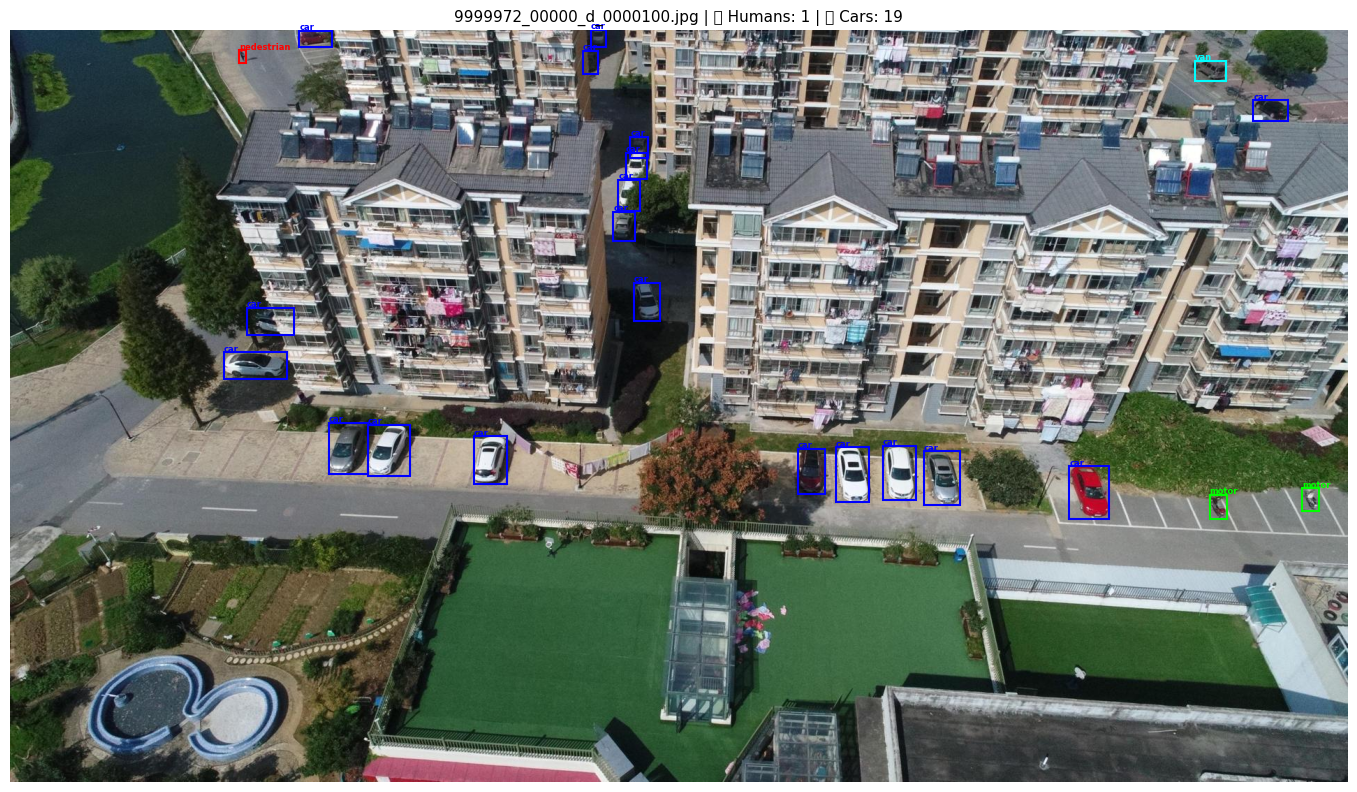

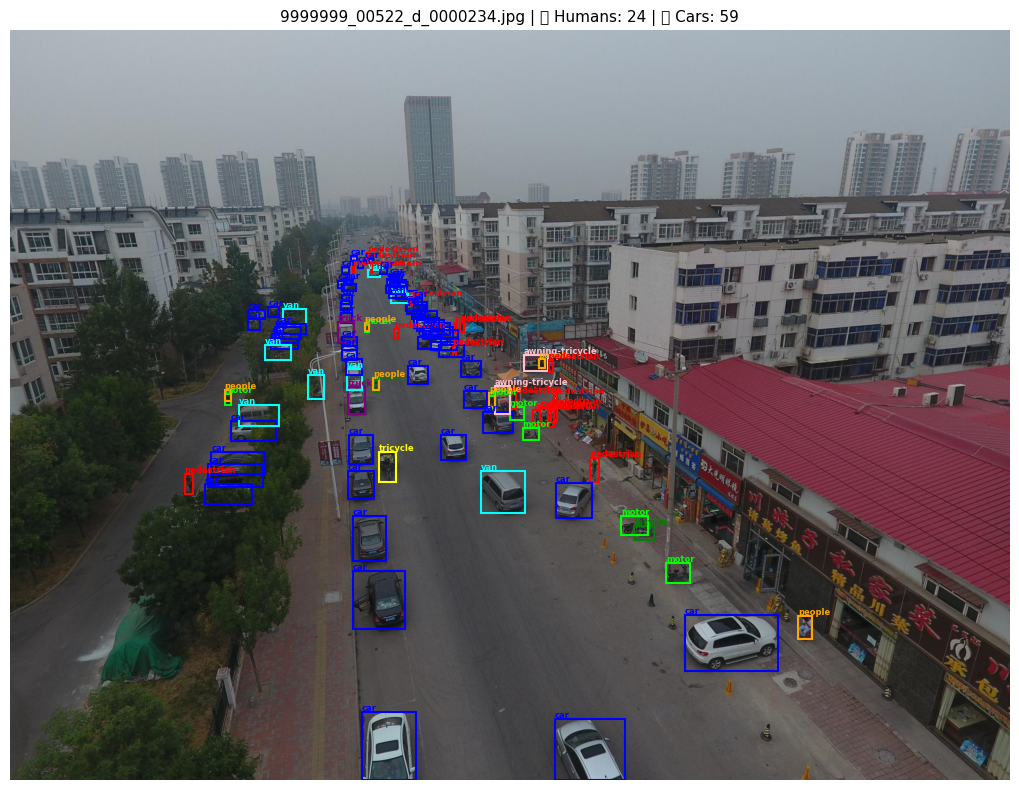

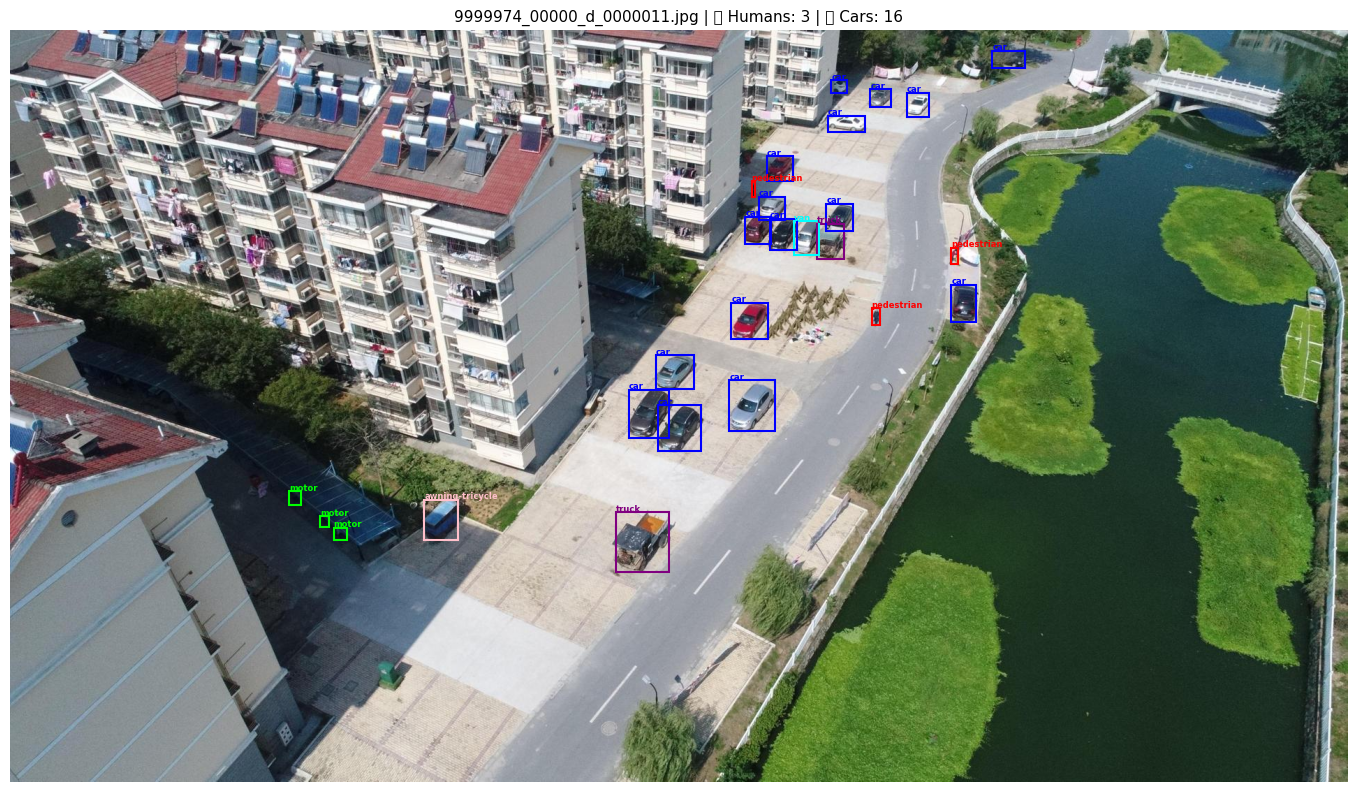

In [4]:
# === VISUALIZE RANDOM IMAGES WITH BOUNDING BOXES ===

def visualize_image(img_name):
    img_path = os.path.join(train_img, img_name)
    lbl_path = os.path.join(train_lbl, img_name.replace('.jpg', '.txt'))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    ax.imshow(img)

    pedestrian_count = 0
    car_count = 0

    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            cls = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])

            # Convert YOLO format back to pixel coords
            x = (cx - bw/2) * w
            y = (cy - bh/2) * h
            bw_px = bw * w
            bh_px = bh * h

            color = COLORS.get(cls, 'white')
            label = CLASSES.get(cls, str(cls))

            rect = patches.Rectangle((x, y), bw_px, bh_px,
                                      linewidth=1.5,
                                      edgecolor=color,
                                      facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y - 2, label, color=color, fontsize=6, fontweight='bold')

            if cls in [0, 1]:
                pedestrian_count += 1
            elif cls == 3:
                car_count += 1

    ax.set_title(f"{img_name} | 🚶 Humans: {pedestrian_count} | 🚗 Cars: {car_count}",
                 fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize 5 random images
for img_name in random.sample(images, 5):
    visualize_image(img_name)

In [5]:
# === DATASET STATISTICS ===
print("📊 Analyzing dataset (first 500 images)...")

counts = {i: 0 for i in range(10)}
total_objects = 0
images_with_humans = 0

for lbl_file in labels[:500]:
    lbl_path = os.path.join(train_lbl, lbl_file)
    has_human = False
    with open(lbl_path, 'r') as f:
        for line in f:
            cls = int(line.strip().split()[0])
            counts[cls] += 1
            total_objects += 1
            if cls in [0, 1]:
                has_human = True
    if has_human:
        images_with_humans += 1

print(f"\nTotal objects (500 images): {total_objects}")
print(f"Images with humans: {images_with_humans}/500")
print(f"\nClass breakdown:")
for cls_id, cnt in counts.items():
    if cnt > 0:
        print(f"  {CLASSES[cls_id]:20s}: {cnt}")

📊 Analyzing dataset (first 500 images)...

Total objects (500 images): 40396
Images with humans: 464/500

Class breakdown:
  pedestrian          : 13245
  people              : 6185
  bicycle             : 2245
  car                 : 11291
  van                 : 1209
  truck               : 807
  tricycle            : 645
  awning-tricycle     : 469
  bus                 : 377
  motor               : 3923


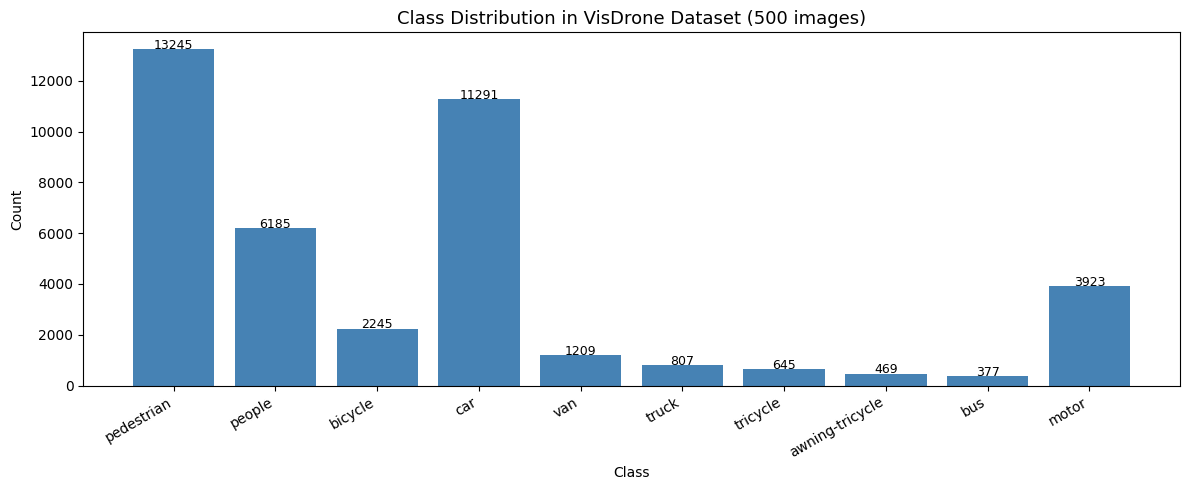

In [6]:
# === BAR CHART OF CLASS DISTRIBUTION ===
fig, ax = plt.subplots(figsize=(12, 5))

class_names = [CLASSES[i] for i in range(10) if counts[i] > 0]
class_counts = [counts[i] for i in range(10) if counts[i] > 0]

bars = ax.bar(class_names, class_counts, color='steelblue')
ax.set_title('Class Distribution in VisDrone Dataset (500 images)', fontsize=13)
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')

for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
# === CHECK YAML FILE ===
yaml_path = f"{base}/visdrone.yaml"

with open(yaml_path, 'r') as f:
    print(f.read())

# VisDrone Dataset Configuration
path: ./VisDrone_Dataset
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-dev/images

#number of classes
nc: 10

# Class names
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor



In [8]:
# === STEP 3: TRAIN YOLOv8 ON VISDRONE ===

# Install ultralytics
!pip install ultralytics -q

from ultralytics import YOLO
import yaml
import shutil
import os

print("✅ Ultralytics installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 102.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.2

In [9]:
# === CREATE CORRECTED YAML ===
# The original yaml has relative paths — we fix them for Kaggle

base = "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset"

custom_yaml = {
    'path': base,
    'train': 'VisDrone2019-DET-train/images',
    'val': 'VisDrone2019-DET-val/images',
    'test': 'VisDrone2019-DET-test-dev/images',
    'nc': 10,
    'names': {
        0: 'pedestrian',
        1: 'people',
        2: 'bicycle',
        3: 'car',
        4: 'van',
        5: 'truck',
        6: 'tricycle',
        7: 'awning-tricycle',
        8: 'bus',
        9: 'motor'
    }
}

yaml_save_path = '/kaggle/working/visdrone_custom.yaml'
with open(yaml_save_path, 'w') as f:
    yaml.dump(custom_yaml, f, default_flow_style=False, allow_unicode=True)

print("✅ Custom YAML saved")
print(open(yaml_save_path).read())

✅ Custom YAML saved
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
nc: 10
path: /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset
test: VisDrone2019-DET-test-dev/images
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images



In [10]:
# === LOAD MODEL ===
# YOLOv8s = small model, good balance of speed and accuracy
model = YOLO('yolov8s.pt')
print("✅ YOLOv8s loaded")

✅ YOLOv8s loaded


In [11]:
# === TRAIN ===
results = model.train(
    data=yaml_save_path,
    epochs=30,
    imgsz=640,
    batch=16,
    name='visdrone_yolov8s',
    project='/kaggle/working/runs',
    pretrained=True,
    optimizer='AdamW',
    lr0=0.001,
    patience=10,
    save=True,
    plots=True,
    verbose=True,
    workers=2,
)

print("✅ Training complete!")

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visdrone_custom.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visdrone_yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask

Saved weights:
  /kaggle/working/runs/visdrone_yolov8s/weights/last.pt
  /kaggle/working/runs/visdrone_yolov8s/weights/best.pt


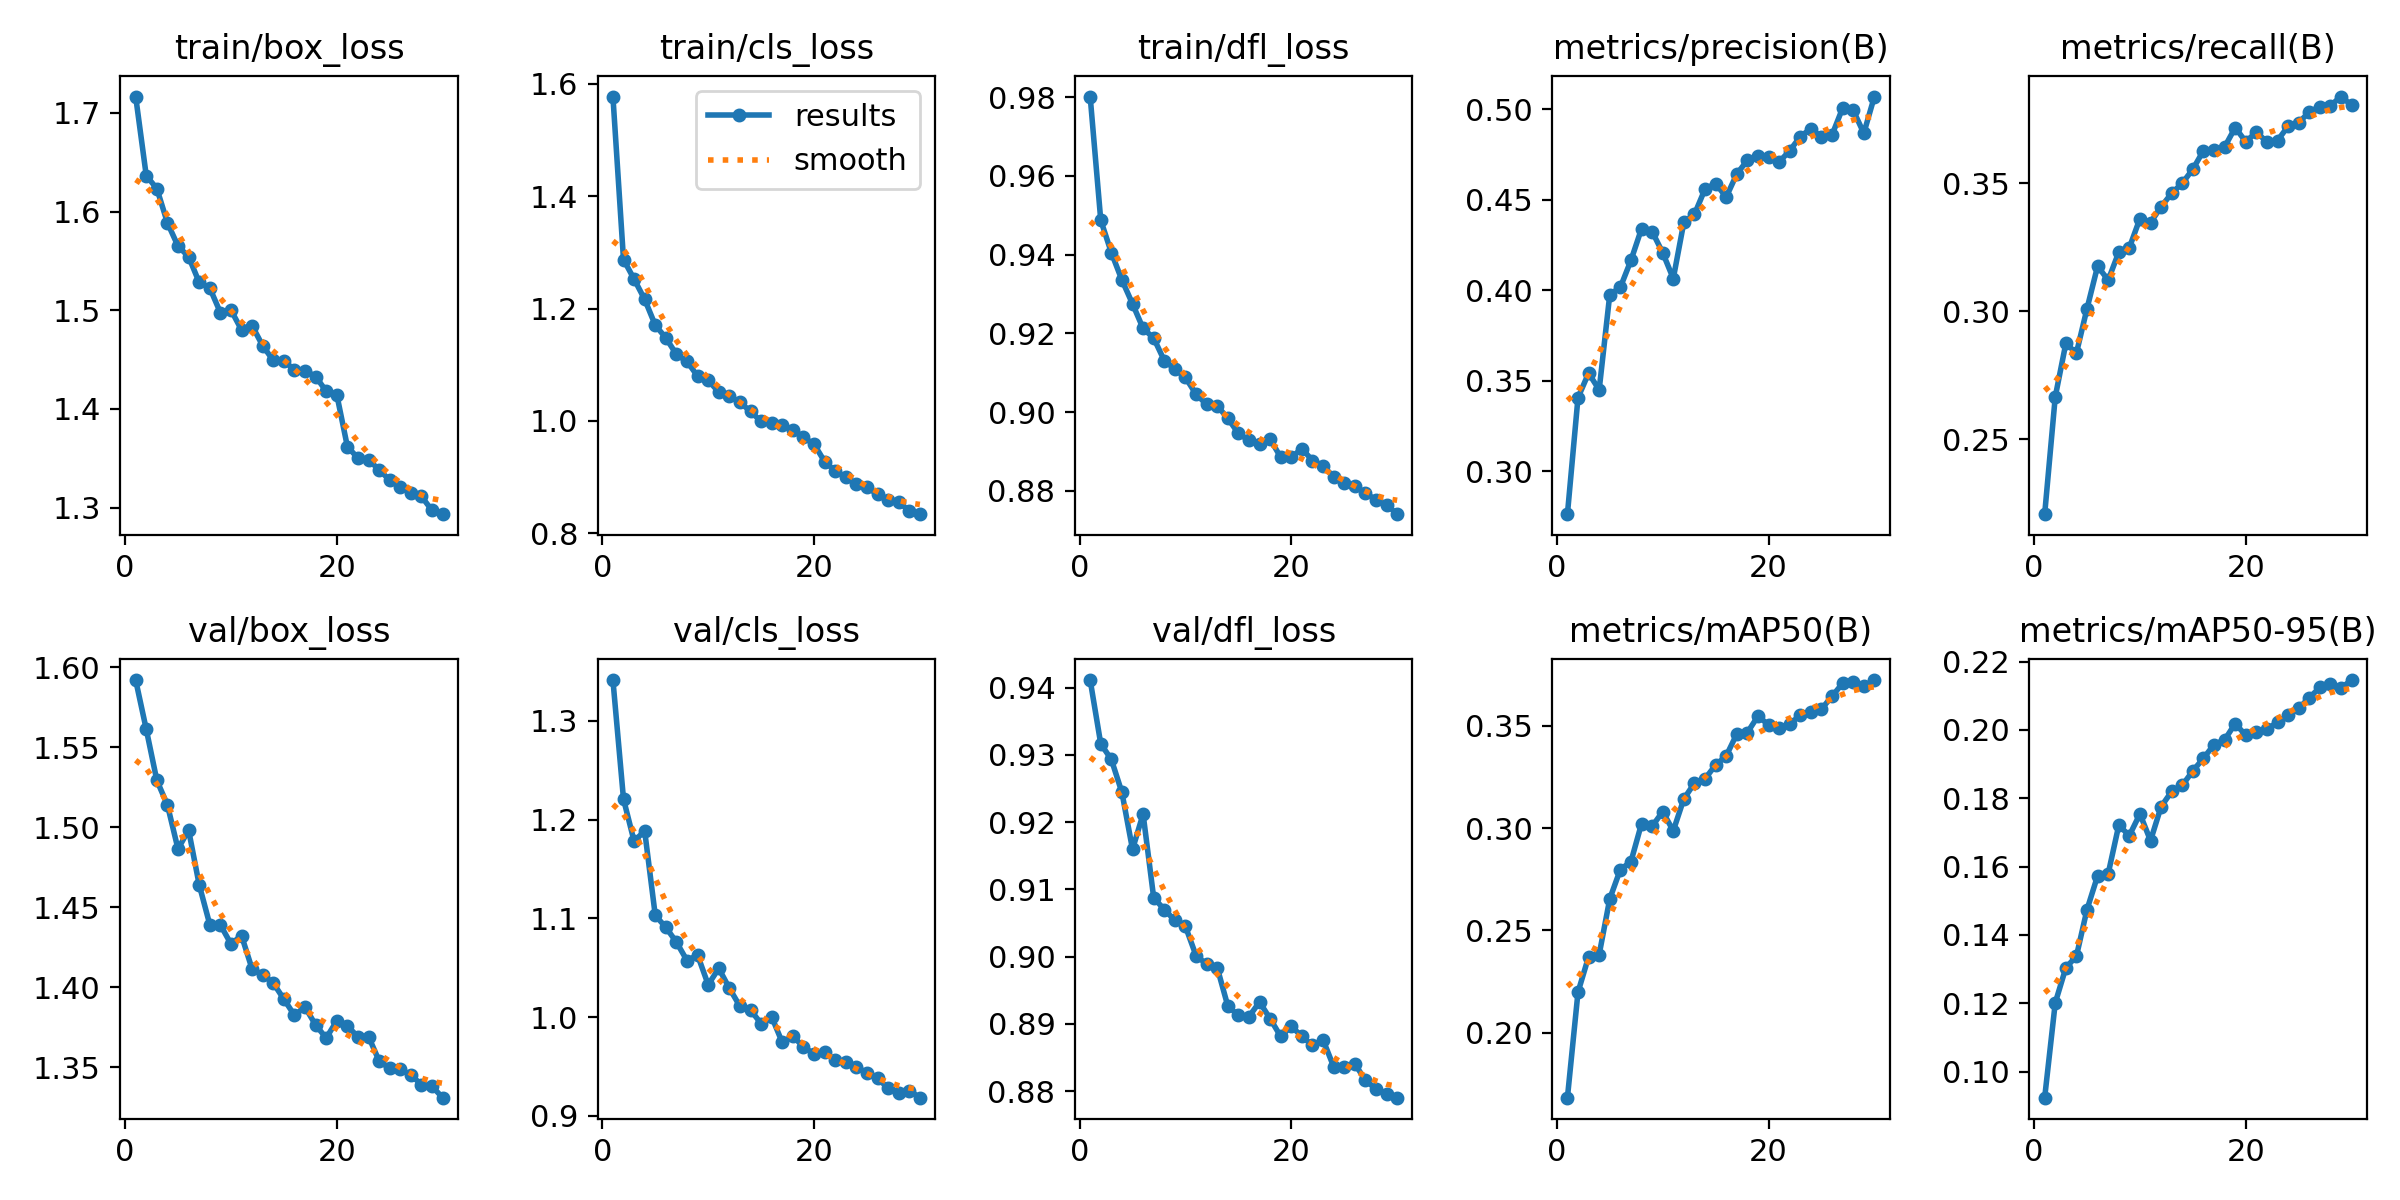

In [12]:
# === CHECK RESULTS ===
import glob

# Find best weights
weights = glob.glob('/kaggle/working/runs/visdrone_yolov8s/weights/*.pt')
print("Saved weights:")
for w in weights:
    print(f"  {w}")

# Show training plots
from IPython.display import Image, display

results_img = '/kaggle/working/runs/visdrone_yolov8s/results.png'
if os.path.exists(results_img):
    display(Image(results_img))